In [1]:
import numpy as np
import torch
import torch.nn as nn
import csv
from importance import prepare_image, get_model_labels, load_model, get_labels, compute_subset_importance, compute_per_sample_gradient, compute_softmax_prob
from regularization import RegParameters, Perturbation, Regularization
from typing import List, Optional
import cv2 as cv
import os
import gc
import matplotlib.pyplot as plt
from torchvision.io import read_image
from torchvision.models import resnet50 #, ResNet50_Weights
import os
import cv2 as cv
import numpy as np
import torch.nn.functional as F
from regularization import Perturbation, Regularization, RegParameters
import json
import gc
import time

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
if not torch.cuda.is_available():
    try:
        if torch.backends.mps.is_available():
            device = torch.device("mps")
    except ImportError:
        pass
print(f"Using device: {device}")

Using device: mps
Using device: mps


In [2]:
def compute_importance(gradients: torch.Tensor,n_samples: int ,estimation: str = 'var', softmax_prob : Optional[torch.Tensor] = None) -> float:
    """
    Computes an importance measure from the gradients using the Regularization helper.
    
    :param gradients: Tensor of gradients of shape (B, C, H, W).
    :param estimation: Estimation method to use ('var' or 'ent').
    :param n_samples: Number of samples used for the perturbation.
    :param softmax_prob: The softmax probability for the specified label for each input image.
    :return: A scalar importance measure.
    """
    importance = Regularization.get_image_importance_by_estimation(gradients, n_samples, estimation, softmax_prob)
    importance = importance.detach().clone()  # Ensure no graph connection
    
    return importance

In [3]:
def compute_softmax_prob(model: torch.nn.Module, images: torch.Tensor, label_idx: int) -> torch.Tensor:
    """
    Computes the softmax probability for a specified label for each input image.
    
    :param model: The neural network model.
    :param
    :param label_idx: The index of the label for which to compute the probability.
    :return: A tensor of shape (B,) with the softmax probability for each image.
    """
    #label_idx  =250
    print(label_idx)
    print('********')
    # Compute the output logits for each image
    logits = model(images)
    print(logits[:, label_idx])
    
    # Compute the softmax probabilities for the specified label
    softmax_probs = F.softmax(logits, dim=1)[:, label_idx]
    print(softmax_probs)
    
    return softmax_probs


In [4]:
def compute_per_sample_gradient(model: torch.nn.Module, images: torch.Tensor, label_idx: int) -> torch.Tensor:
    """
    Computes the gradient of the softmax probability for a specified label with respect 
    to each input image.
    
    :param model: The neural network model.
    :param images: A batch of images of shape (B, C, H, W). Must have requires_grad=True.
    :param label_idx: The index of the label for which to compute the gradient.
    :return: A tensor of shape (B, C, H, W) with the gradient for each image.
    """
    def f(x: torch.Tensor) -> torch.Tensor:
        # x has shape (C, H, W); add batch dimension
        out = model(x.unsqueeze(0))              # shape: (1, num_classes)
        out_sm = F.softmax(out, dim=1)             # shape: (1, num_classes)
        probab = out_sm[0, label_idx]                # shape: (1,)
        #probab = out[0, label_idx]                # shape: (1,)
        return probab  # return the probability for the specified label


    with torch.autograd.set_grad_enabled(True):
        # runs forward pass
        outputs = compute_softmax_prob(model, images, label_idx)
        assert outputs[0].numel() == 1, (
        "Target not provided when necessary, cannot"
        " take gradient with respect to multiple outputs."
        )
        # torch.unbind(forward_out) is a list of scalar tensor tuples and
        # contains batch_size * #steps elements
        grads = torch.autograd.grad(torch.unbind(outputs), images)[0]

    return grads  # shape: (B, C, H, W)

In [5]:
def compute_image_importance(model: nn.Module, images: torch.Tensor, 
                              label_idx: int, reg_params: RegParameters) -> float:
    """
    Computes the importance measure for a subset of pixels for a given label by perturbing the images
    on that subset, computing the softmax probability, and then calculating the gradient with respect
    to the inputs.
    
    :param model: The neural network model.
    :param images: A batch of images of shape (B, C, H, W).
    :param pixels: List of pixel indices (flattened) to include in the perturbation.
    :param label_idx: The index of the label for which to compute the gradient.
    :param reg_params: Regularization parameters.
    :return: A scalar importance measure for the pixel subset.
    """
    pertub_images = Perturbation.perturb_tensor(images, reg_params.n_samples)
    print(f"pertub_images shape: {pertub_images.shape}")
    pertub_images.requires_grad_(True)
    per_sample_grad = compute_per_sample_gradient(model, pertub_images, label_idx)
    print(f"per_sample_grad shape: {per_sample_grad.shape}")
    #per_sample_grad = compute_per_pixel_gradient(model, pertub_images, label_idx, pixels, reg_params.n_samples)
    softmax_prob = None
    
    if reg_params.estimation != 'var':
        softmax_prob = compute_softmax_prob(model, pertub_images, label_idx)

    importance = compute_importance(per_sample_grad, reg_params.n_samples, estimation=reg_params.estimation, softmax_prob=softmax_prob)
    print(f"importance shape: {importance.shape}")

    pertub_images = pertub_images.detach().clone()  # Stop tracking grads to avoid OOM
    per_sample_grad = per_sample_grad.detach().clone()

    del pertub_images, per_sample_grad  # Delete the intermediate tensors to free up memory
    return importance


In [6]:
def compute_importance_image(
    model: nn.Module,
    image: torch.Tensor,
    label_idx: int,
    reg_params: RegParameters,
    batch_size: int = 64,
    pixel_list: Optional[List[int]] = None,
    sal_map: Optional[np.ndarray] = None
) -> torch.Tensor:
    """
    Computes an importance score for a *subset of pixels* in a single image for a specific label,
    using batched perturbations. If no pixel_list is provided, it processes all pixels.

    :param model: The neural network model (eval mode).
    :param image: A single image tensor of shape (1, 3, H, W) with requires_grad=True.
    :param label_idx: The class index for which to compute pixel importance.
    :param reg_params: Regularization or sampling parameters (e.g., n_samples).
    :param save_path: File path to which the computed per-pixel results will be appended.
    :param batch_size: Number of pixels to process in one batch for GPU efficiency.
    :param pixel_list: A list of pixel indices to process. If None, we default to all pixels.
    :return: A 1D tensor of size len(pixel_list) or size (H*W) if pixel_list=None,
             containing the computed importance for each pixel in the requested subset.
    """
    device_ = image.device

    # 1) Infer shape and number of pixels
    _, C, H, W = image.shape
    total_pixels = H * W

    # 2) If no pixel_list provided, default to all pixels in [0..H*W-1]
    if pixel_list is None:
        if sal_map is not None:
            sal_map = sal_map.to(device_)
            sal_map = sal_map.view(-1)
            return sal_map

        pixel_list = list(range(total_pixels))
                        

    # 3) Prepare an output tensor for the subset, shape [len(pixel_list)]
    subset_size = len(pixel_list)
    saliency_subset = torch.zeros((subset_size,), device=device_) 
    
    importance_batch = compute_image_importance(
            model=model,
            images=image,
            label_idx=label_idx,
            reg_params=reg_params
        ) 
    
    return importance_batch

    iter_count = 0

    # 4) Process the subset in batches
    for start_idx in range(0, subset_size, batch_size): 
        iter_count += 1
        end_idx = min(start_idx + batch_size, subset_size)
        batch_indices = pixel_list[start_idx:end_idx]

        # 4a) Pass this batch of pixels to the "compute_subset_importance" function
        #     which should uniformly sample each pixel in 'batch_indices' and return
        #     a 1D tensor of shape (len(batch_indices),)
        importance_batch = compute_image_importance(
            model=model,
            images=image,
            pixels=batch_indices,
            label_idx=label_idx,
            reg_params=reg_params
        )  
        # e.g., shape: (len(batch_indices),)
        #print(importance_batch.shape, "importance_batch.shape,  shape: (len(batch_indices),)")

        saliency_subset[start_idx : end_idx] = importance_batch

        if iter_count % 100:
            print(f"Processed {end_idx}/{subset_size} pixels.")
            #return saliency_subset #cancel this line to get the full image

    # 5) Return the importance for the requested subset.
    #    The caller can reshape if needed (e.g., (H, W) if the subset is all pixels).
    return saliency_subset

In [7]:
def do_initial_pass_uniform(
    model, image, label_idx, reg_params,
    global_batch_size_for_perturbations,
    n_init, csv_path, sal_map=None
):
    """
    1) Samples each pixel exactly n_init times (uniform).
    2) Returns an array of shape (num_pixels,) with the initial importance estimate.
    """
    # We'll assume there's a function `compute_importance_batch`
    # that can handle a 'pixel_list=None' to mean "all pixels".
    
    old_n_samples = reg_params.n_samples
    reg_params.n_samples = n_init
    
    # We pass pixel_list=None (or the entire range) if your function defaults to all pixels
    uniform_init_map = compute_importance_image(
        model=model,
        image=image,
        label_idx=label_idx,
        reg_params=reg_params,
        batch_size=global_batch_size_for_perturbations,
        pixel_list=None,  # or range(num_pixels),
        sal_map = sal_map
    )
    #print('uniform_init_map.shape:', uniform_init_map.shape)
    
    # Restore original n_samples
    reg_params.n_samples = old_n_samples

    _, C, H, W = image.shape
    total_pixels = H * W
    pixel_list = list(range(total_pixels))
    n_total = n_init * total_pixels

    num_pixels = total_pixels
    importance_est = np.zeros(num_pixels, dtype=np.float32)
    n_i = np.zeros(num_pixels, dtype=np.int32)
    final_map = uniform_init_map.squeeze(0)
    
    #print("shape of uniform_init_map:", uniform_init_map.shape)
    #print("uniform_init_map:", uniform_init_map)
    #print("shape of importance_est:", importance_est.shape)
    #print("importance_est:", importance_est)
    #print("shape of final_map:", final_map.shape)
    #print("final_map:", final_map)

    
    return uniform_init_map, n_i, importance_est, final_map

    for i in range(num_pixels):
        n_i[i] = n_init
        importance_est[i] = uniform_init_map[i].item()
        
    final_map = torch.from_numpy(importance_est.reshape(H, W))      

    #ucb_scores = compute_ucb_scores(importance_est, n_i, n_total, reg_params.c)

    #if sal_map is None:
    #    log_csv_batch(csv_path, 0, pixel_list, ucb_scores, importance_est, n_i, n_total)

    return uniform_init_map, n_i, importance_est, final_map

In [8]:
def generate_image_importance_map(
    image_path: str, 
    model: nn.Module, 
    labels: list, 
    reg_params,
    ucb_iterations: int = 5,
    top_percent: float = 0.1,
    batch_size_for_perturbations: int = 64,
    n_init: int = 3,
    csv_path: str = "ucb_log.csv",
    calculate: bool = True
) -> None:
    """
    Similar to the old `generate_information_map`, but uses the new UCB-based partial sort approach.
    For each label found in the filename, we compute a pixel-level importance map with:
      1) an initial uniform pass of n_init,
      2) a UCB outer loop for ucb_iterations steps, each partial-sorting top_percent of pixels.
    Finally, display and save the original image plus these saliency maps.

    :param image_path: Path to the image file (filename must contain labels separated by '_').
    :param model: The classification model in eval mode.
    :param labels: List of valid class labels.
    :param reg_params: A RegParameters instance containing e.g. c, n_samples, estimation, etc.
    :param ucb_iterations: Number of times to repeat the partial-sort UCB steps.
    :param top_percent: Fraction of pixels to pick each iteration.
    :param batch_size_for_perturbations: Batch size for calls to `compute_pixel_level_importance_batch`.
    :param n_init: Number of uniform perturbations per pixel in the initial pass.
    :param csv_path: Where to log each iteration's chosen pixels (in CSV format).
    """

    # 1) Load & preprocess the image
    img, img_tensor = prepare_image(image_path)
    img_tensor.requires_grad_(True)

    # 2) Parse labels from filename
    gt_labels = get_labels(image_path)
    name_no_ext = gt_labels[0] + "_" + gt_labels[1]

    # 3) For each ground-truth label in the filename, do the UCB approach
    info_maps = {}
    for label in gt_labels:
        #if label == gt_labels[0]:
        #    continue
        try:
            label_idx = labels.index(label)
        except ValueError:
            print(f"Label '{label}' not found in the provided labels list.")
            continue

        # We choose a separate text file for the initial pass log
        save_dir = f"{name_no_ext}/{label}/"
        csv_path = f"{save_dir}ucb_log.csv"
        #ensure_dir_exists(csv_path)

        if False:
            print(f"[UCB] Computing information map for label: {label}")
            if not os.path.exists(csv_path):
                log_csv_header(csv_path)
                last_ucb_t = 0
                sal_map = None
            else:
                _, C, H, W = img_tensor.shape
                sal_map, last_ucb_t = load_importance_map_from_csv(H, W ,csv_path) 

            # 4) Call the new modular UCB-based function
            sal_map = compute_pixel_importance_ucb_wrapper_partialsort(
                model=model,
                image=img_tensor,
                label_idx=label_idx,
                reg_params=reg_params,
                ucb_iterations=ucb_iterations,
                top_percent=top_percent,
                global_batch_size_for_perturbations=batch_size_for_perturbations,
                n_init=n_init,
                csv_path=csv_path,
                sal_map = sal_map,
                last_ucb_t = int(last_ucb_t)
            )
            sal_map = sal_map.detach().cpu().numpy()
        else:
            _, C, H, W = img_tensor.shape
            uniform_init_map, n_i, importance_est, sal_map = do_initial_pass_uniform(
                        model, img_tensor, label_idx, reg_params,
                        batch_size_for_perturbations,
                        n_init, csv_path, sal_map=None)
            #sal_map, ucb_iteration = load_importance_map_from_csv(H, W ,csv_path) 

            sal_map = (sal_map - sal_map.min())/ (sal_map.max() - sal_map.min() + 1e-8)
            sal_map_uint8 = (sal_map.detach().cpu().numpy() * 255).astype(np.uint8)
            colored_sal_map = cv.applyColorMap(sal_map_uint8, cv.COLORMAP_JET)
            alpha = 0.3  # Transparency factor
            sal_map = cv.addWeighted(img, alpha, colored_sal_map, 1 - alpha, 0)

        info_maps[label] = sal_map

        # optional memory cleanup
        del sal_map
        torch.cuda.empty_cache()
        gc.collect()

    # 5) Display results
    num_plots = len(info_maps) + 1
    fig, axes = plt.subplots(1, num_plots, figsize=(5 * num_plots, 5))
    axes[0].imshow(img)
    axes[0].set_title("Original Image")
    axes[0].axis("off")
    for i, (label, info_map) in enumerate(info_maps.items(), start=1):
        #axes[i].imshow(info_map, cmap='hot')
        axes[i].imshow(cv.cvtColor(info_map, cv.COLOR_BGR2RGB)) #
        axes[i].set_title(f"UCB Info Map: {label}")
        axes[i].axis("off")
    plt.tight_layout()
    plt.show()

    save_dir = save_dir.split('/')[0] + '/'
    info_map_path = f"{save_dir}image_info_map.png"
    fig.savefig(info_map_path)
    print(f"UCB-based information map saved to {info_map_path}")

    del info_maps, img_tensor
    torch.cuda.empty_cache()
    gc.collect()

In [9]:
from resnet50 import resnet50, resnet50_v2
IMAGE_PATH = "images2explain/bull mastiff_tabby.png"
    
try:
    from torchvision.models import ResNet50_Weights
    weights = ResNet50_Weights.DEFAULT
    labels = weights.meta["categories"]
    #model = resnet50(weights=weights)
    model = resnet50_v2(pretrained=True, progress=True)
except ImportError:
    labels = ['tench', 'goldfish', 'great white shark', 'tiger shark', 'hammerhead', 'electric ray', 'stingray', 'cock', 'hen', 'ostrich', 'brambling', 'goldfinch', 'house finch', 'junco', 'indigo bunting', 'robin', 'bulbul', 'jay', 'magpie', 'chickadee', 'water ouzel', 'kite', 'bald eagle', 'vulture', 'great grey owl', 'European fire salamander', 'common newt', 'eft', 'spotted salamander', 'axolotl', 'bullfrog', 'tree frog', 'tailed frog', 'loggerhead', 'leatherback turtle', 'mud turtle', 'terrapin', 'box turtle', 'banded gecko', 'common iguana', 'American chameleon', 'whiptail', 'agama', 'frilled lizard', 'alligator lizard', 'Gila monster', 'green lizard', 'African chameleon', 'Komodo dragon', 'African crocodile', 'American alligator', 'triceratops', 'thunder snake', 'ringneck snake', 'hognose snake', 'green snake', 'king snake', 'garter snake', 'water snake', 'vine snake', 'night snake', 'boa constrictor', 'rock python', 'Indian cobra', 'green mamba', 'sea snake', 'horned viper', 'diamondback', 'sidewinder', 'trilobite', 'harvestman', 'scorpion', 'black and gold garden spider', 'barn spider', 'garden spider', 'black widow', 'tarantula', 'wolf spider', 'tick', 'centipede', 'black grouse', 'ptarmigan', 'ruffed grouse', 'prairie chicken', 'peacock', 'quail', 'partridge', 'African grey', 'macaw', 'sulphur-crested cockatoo', 'lorikeet', 'coucal', 'bee eater', 'hornbill', 'hummingbird', 'jacamar', 'toucan', 'drake', 'red-breasted merganser', 'goose', 'black swan', 'tusker', 'echidna', 'platypus', 'wallaby', 'koala', 'wombat', 'jellyfish', 'sea anemone', 'brain coral', 'flatworm', 'nematode', 'conch', 'snail', 'slug', 'sea slug', 'chiton', 'chambered nautilus', 'Dungeness crab', 'rock crab', 'fiddler crab', 'king crab', 'American lobster', 'spiny lobster', 'crayfish', 'hermit crab', 'isopod', 'white stork', 'black stork', 'spoonbill', 'flamingo', 'little blue heron', 'American egret', 'bittern', 'crane bird', 'limpkin', 'European gallinule', 'American coot', 'bustard', 'ruddy turnstone', 'red-backed sandpiper', 'redshank', 'dowitcher', 'oystercatcher', 'pelican', 'king penguin', 'albatross', 'grey whale', 'killer whale', 'dugong', 'sea lion', 'Chihuahua', 'Japanese spaniel', 'Maltese dog', 'Pekinese', 'Shih-Tzu', 'Blenheim spaniel', 'papillon', 'toy terrier', 'Rhodesian ridgeback', 'Afghan hound', 'basset', 'beagle', 'bloodhound', 'bluetick', 'black-and-tan coonhound', 'Walker hound', 'English foxhound', 'redbone', 'borzoi', 'Irish wolfhound', 'Italian greyhound', 'whippet', 'Ibizan hound', 'Norwegian elkhound', 'otterhound', 'Saluki', 'Scottish deerhound', 'Weimaraner', 'Staffordshire bullterrier', 'American Staffordshire terrier', 'Bedlington terrier', 'Border terrier', 'Kerry blue terrier', 'Irish terrier', 'Norfolk terrier', 'Norwich terrier', 'Yorkshire terrier', 'wire-haired fox terrier', 'Lakeland terrier', 'Sealyham terrier', 'Airedale', 'cairn', 'Australian terrier', 'Dandie Dinmont', 'Boston bull', 'miniature schnauzer', 'giant schnauzer', 'standard schnauzer', 'Scotch terrier', 'Tibetan terrier', 'silky terrier', 'soft-coated wheaten terrier', 'West Highland white terrier', 'Lhasa', 'flat-coated retriever', 'curly-coated retriever', 'golden retriever', 'Labrador retriever', 'Chesapeake Bay retriever', 'German short-haired pointer', 'vizsla', 'English setter', 'Irish setter', 'Gordon setter', 'Brittany spaniel', 'clumber', 'English springer', 'Welsh springer spaniel', 'cocker spaniel', 'Sussex spaniel', 'Irish water spaniel', 'kuvasz', 'schipperke', 'groenendael', 'malinois', 'briard', 'kelpie', 'komondor', 'Old English sheepdog', 'Shetland sheepdog', 'collie', 'Border collie', 'Bouvier des Flandres', 'Rottweiler', 'German shepherd', 'Doberman', 'miniature pinscher', 'Greater Swiss Mountain dog', 'Bernese mountain dog', 'Appenzeller', 'EntleBucher', 'boxer', 'bull mastiff', 'Tibetan mastiff', 'French bulldog', 'Great Dane', 'Saint Bernard', 'Eskimo dog', 'malamute', 'Siberian husky', 'dalmatian', 'affenpinscher', 'basenji', 'pug', 'Leonberg', 'Newfoundland', 'Great Pyrenees', 'Samoyed', 'Pomeranian', 'chow', 'keeshond', 'Brabancon griffon', 'Pembroke', 'Cardigan', 'toy poodle', 'miniature poodle', 'standard poodle', 'Mexican hairless', 'timber wolf', 'white wolf', 'red wolf', 'coyote', 'dingo', 'dhole', 'African hunting dog', 'hyena', 'red fox', 'kit fox', 'Arctic fox', 'grey fox', 'tabby', 'tiger cat', 'Persian cat', 'Siamese cat', 'Egyptian cat', 'cougar', 'lynx', 'leopard', 'snow leopard', 'jaguar', 'lion', 'tiger', 'cheetah', 'brown bear', 'American black bear', 'ice bear', 'sloth bear', 'mongoose', 'meerkat', 'tiger beetle', 'ladybug', 'ground beetle', 'long-horned beetle', 'leaf beetle', 'dung beetle', 'rhinoceros beetle', 'weevil', 'fly', 'bee', 'ant', 'grasshopper', 'cricket', 'walking stick', 'cockroach', 'mantis', 'cicada', 'leafhopper', 'lacewing', 'dragonfly', 'damselfly', 'admiral', 'ringlet', 'monarch', 'cabbage butterfly', 'sulphur butterfly', 'lycaenid', 'starfish', 'sea urchin', 'sea cucumber', 'wood rabbit', 'hare', 'Angora', 'hamster', 'porcupine', 'fox squirrel', 'marmot', 'beaver', 'guinea pig', 'sorrel', 'zebra', 'hog', 'wild boar', 'warthog', 'hippopotamus', 'ox', 'water buffalo', 'bison', 'ram', 'bighorn', 'ibex', 'hartebeest', 'impala', 'gazelle', 'Arabian camel', 'llama', 'weasel', 'mink', 'polecat', 'black-footed ferret', 'otter', 'skunk', 'badger', 'armadillo', 'three-toed sloth', 'orangutan', 'gorilla', 'chimpanzee', 'gibbon', 'siamang', 'guenon', 'patas', 'baboon', 'macaque', 'langur', 'colobus', 'proboscis monkey', 'marmoset', 'capuchin', 'howler monkey', 'titi', 'spider monkey', 'squirrel monkey', 'Madagascar cat', 'indri', 'Indian elephant', 'African elephant', 'lesser panda', 'giant panda', 'barracouta', 'eel', 'coho', 'rock beauty', 'anemone fish', 'sturgeon', 'gar', 'lionfish', 'puffer', 'abacus', 'abaya', 'academic gown', 'accordion', 'acoustic guitar', 'aircraft carrier', 'airliner', 'airship', 'altar', 'ambulance', 'amphibian', 'analog clock', 'apiary', 'apron', 'ashcan', 'assault rifle', 'backpack', 'bakery', 'balance beam', 'balloon', 'ballpoint', 'Band Aid', 'banjo', 'bannister', 'barbell', 'barber chair', 'barbershop', 'barn', 'barometer', 'barrel', 'barrow', 'baseball', 'basketball', 'bassinet', 'bassoon', 'bathing cap', 'bath towel', 'bathtub', 'beach wagon', 'beacon', 'beaker', 'bearskin', 'beer bottle', 'beer glass', 'bell cote', 'bib', 'bicycle-built-for-two', 'bikini', 'binder', 'binoculars', 'birdhouse', 'boathouse', 'bobsled', 'bolo tie', 'bonnet', 'bookcase', 'bookshop', 'bottlecap', 'bow', 'bow tie', 'brass', 'brassiere', 'breakwater', 'breastplate', 'broom', 'bucket', 'buckle', 'bulletproof vest', 'bullet train', 'butcher shop', 'cab', 'caldron', 'candle', 'cannon', 'canoe', 'can opener', 'cardigan', 'car mirror', 'carousel', "carpenter's kit", 'carton', 'car wheel', 'cash machine', 'cassette', 'cassette player', 'castle', 'catamaran', 'CD player', 'cello', 'cellular telephone', 'chain', 'chainlink fence', 'chain mail', 'chain saw', 'chest', 'chiffonier', 'chime', 'china cabinet', 'Christmas stocking', 'church', 'cinema', 'cleaver', 'cliff dwelling', 'cloak', 'clog', 'cocktail shaker', 'coffee mug', 'coffeepot', 'coil', 'combination lock', 'computer keyboard', 'confectionery', 'container ship', 'convertible', 'corkscrew', 'cornet', 'cowboy boot', 'cowboy hat', 'cradle', 'crane', 'crash helmet', 'crate', 'crib', 'Crock Pot', 'croquet ball', 'crutch', 'cuirass', 'dam', 'desk', 'desktop computer', 'dial telephone', 'diaper', 'digital clock', 'digital watch', 'dining table', 'dishrag', 'dishwasher', 'disk brake', 'dock', 'dogsled', 'dome', 'doormat', 'drilling platform', 'drum', 'drumstick', 'dumbbell', 'Dutch oven', 'electric fan', 'electric guitar', 'electric locomotive', 'entertainment center', 'envelope', 'espresso maker', 'face powder', 'feather boa', 'file', 'fireboat', 'fire engine', 'fire screen', 'flagpole', 'flute', 'folding chair', 'football helmet', 'forklift', 'fountain', 'fountain pen', 'four-poster', 'freight car', 'French horn', 'frying pan', 'fur coat', 'garbage truck', 'gasmask', 'gas pump', 'goblet', 'go-kart', 'golf ball', 'golfcart', 'gondola', 'gong', 'gown', 'grand piano', 'greenhouse', 'grille', 'grocery store', 'guillotine', 'hair slide', 'hair spray', 'half track', 'hammer', 'hamper', 'hand blower', 'hand-held computer', 'handkerchief', 'hard disc', 'harmonica', 'harp', 'harvester', 'hatchet', 'holster', 'home theater', 'honeycomb', 'hook', 'hoopskirt', 'horizontal bar', 'horse cart', 'hourglass', 'iPod', 'iron', "jack-o'-lantern", 'jean', 'jeep', 'jersey', 'jigsaw puzzle', 'jinrikisha', 'joystick', 'kimono', 'knee pad', 'knot', 'lab coat', 'ladle', 'lampshade', 'laptop', 'lawn mower', 'lens cap', 'letter opener', 'library', 'lifeboat', 'lighter', 'limousine', 'liner', 'lipstick', 'Loafer', 'lotion', 'loudspeaker', 'loupe', 'lumbermill', 'magnetic compass', 'mailbag', 'mailbox', 'maillot', 'maillot tank suit', 'manhole cover', 'maraca', 'marimba', 'mask', 'matchstick', 'maypole', 'maze', 'measuring cup', 'medicine chest', 'megalith', 'microphone', 'microwave', 'military uniform', 'milk can', 'minibus', 'miniskirt', 'minivan', 'missile', 'mitten', 'mixing bowl', 'mobile home', 'Model T', 'modem', 'monastery', 'monitor', 'moped', 'mortar', 'mortarboard', 'mosque', 'mosquito net', 'motor scooter', 'mountain bike', 'mountain tent', 'mouse', 'mousetrap', 'moving van', 'muzzle', 'nail', 'neck brace', 'necklace', 'nipple', 'notebook', 'obelisk', 'oboe', 'ocarina', 'odometer', 'oil filter', 'organ', 'oscilloscope', 'overskirt', 'oxcart', 'oxygen mask', 'packet', 'paddle', 'paddlewheel', 'padlock', 'paintbrush', 'pajama', 'palace', 'panpipe', 'paper towel', 'parachute', 'parallel bars', 'park bench', 'parking meter', 'passenger car', 'patio', 'pay-phone', 'pedestal', 'pencil box', 'pencil sharpener', 'perfume', 'Petri dish', 'photocopier', 'pick', 'pickelhaube', 'picket fence', 'pickup', 'pier', 'piggy bank', 'pill bottle', 'pillow', 'ping-pong ball', 'pinwheel', 'pirate', 'pitcher', 'plane', 'planetarium', 'plastic bag', 'plate rack', 'plow', 'plunger', 'Polaroid camera', 'pole', 'police van', 'poncho', 'pool table', 'pop bottle', 'pot', "potter's wheel", 'power drill', 'prayer rug', 'printer', 'prison', 'projectile', 'projector', 'puck', 'punching bag', 'purse', 'quill', 'quilt', 'racer', 'racket', 'radiator', 'radio', 'radio telescope', 'rain barrel', 'recreational vehicle', 'reel', 'reflex camera', 'refrigerator', 'remote control', 'restaurant', 'revolver', 'rifle', 'rocking chair', 'rotisserie', 'rubber eraser', 'rugby ball', 'rule', 'running shoe', 'safe', 'safety pin', 'saltshaker', 'sandal', 'sarong', 'sax', 'scabbard', 'scale', 'school bus', 'schooner', 'scoreboard', 'screen', 'screw', 'screwdriver', 'seat belt', 'sewing machine', 'shield', 'shoe shop', 'shoji', 'shopping basket', 'shopping cart', 'shovel', 'shower cap', 'shower curtain', 'ski', 'ski mask', 'sleeping bag', 'slide rule', 'sliding door', 'slot', 'snorkel', 'snowmobile', 'snowplow', 'soap dispenser', 'soccer ball', 'sock', 'solar dish', 'sombrero', 'soup bowl', 'space bar', 'space heater', 'space shuttle', 'spatula', 'speedboat', 'spider web', 'spindle', 'sports car', 'spotlight', 'stage', 'steam locomotive', 'steel arch bridge', 'steel drum', 'stethoscope', 'stole', 'stone wall', 'stopwatch', 'stove', 'strainer', 'streetcar', 'stretcher', 'studio couch', 'stupa', 'submarine', 'suit', 'sundial', 'sunglass', 'sunglasses', 'sunscreen', 'suspension bridge', 'swab', 'sweatshirt', 'swimming trunks', 'swing', 'switch', 'syringe', 'table lamp', 'tank', 'tape player', 'teapot', 'teddy', 'television', 'tennis ball', 'thatch', 'theater curtain', 'thimble', 'thresher', 'throne', 'tile roof', 'toaster', 'tobacco shop', 'toilet seat', 'torch', 'totem pole', 'tow truck', 'toyshop', 'tractor', 'trailer truck', 'tray', 'trench coat', 'tricycle', 'trimaran', 'tripod', 'triumphal arch', 'trolleybus', 'trombone', 'tub', 'turnstile', 'typewriter keyboard', 'umbrella', 'unicycle', 'upright', 'vacuum', 'vase', 'vault', 'velvet', 'vending machine', 'vestment', 'viaduct', 'violin', 'volleyball', 'waffle iron', 'wall clock', 'wallet', 'wardrobe', 'warplane', 'washbasin', 'washer', 'water bottle', 'water jug', 'water tower', 'whiskey jug', 'whistle', 'wig', 'window screen', 'window shade', 'Windsor tie', 'wine bottle', 'wing', 'wok', 'wooden spoon', 'wool', 'worm fence', 'wreck', 'yawl', 'yurt', 'web site', 'comic book', 'crossword puzzle', 'street sign', 'traffic light', 'book jacket', 'menu', 'plate', 'guacamole', 'consomme', 'hot pot', 'trifle', 'ice cream', 'ice lolly', 'French loaf', 'bagel', 'pretzel', 'cheeseburger', 'hotdog', 'mashed potato', 'head cabbage', 'broccoli', 'cauliflower', 'zucchini', 'spaghetti squash', 'acorn squash', 'butternut squash', 'cucumber', 'artichoke', 'bell pepper', 'cardoon', 'mushroom', 'Granny Smith', 'strawberry', 'orange', 'lemon', 'fig', 'pineapple', 'banana', 'jackfruit', 'custard apple', 'pomegranate', 'hay', 'carbonara', 'chocolate sauce', 'dough', 'meat loaf', 'pizza', 'potpie', 'burrito', 'red wine', 'espresso', 'cup', 'eggnog', 'alp', 'bubble', 'cliff', 'coral reef', 'geyser', 'lakeside', 'promontory', 'sandbar', 'seashore', 'valley', 'volcano', 'ballplayer', 'groom', 'scuba diver', 'rapeseed', 'daisy', "yellow lady's slipper", 'corn', 'acorn', 'hip', 'buckeye', 'coral fungus', 'agaric', 'gyromitra', 'stinkhorn', 'earthstar', 'hen-of-the-woods', 'bolete', 'ear', 'toilet tissue']
    #model = resnet50(pretrained=True)
    model = resnet50_v2(pretrained=True, progress=True)
    import json
    import urllib.request
    #LABELS_URL = "https://raw.githubusercontent.com/pytorch/hub/master/imagenet_classes.txt"
    #labels = urllib.request.urlopen(LABELS_URL).read().decode("utf-8").splitlines()

print('model layers:', model)
model.eval()
model.to(device)

reg_params = RegParameters()
reg_params.estimation = 'var'  # e.g. variance-based
reg_params.n_samples = 2
reg_params.c = 0.25

model layers: ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): Bottleneck(
      (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (downsample): Sequential(
        (0): Conv2d(64, 256, kernel_size=(1, 1

pertub_images shape: torch.Size([40, 3, 224, 224])
243
********
in the network
in the network
in the network
in the network
in the network
in the network
in the network
in the network
in the network
in the network
in the network
in the network
in the network
in the network
in the network
in the network
tensor([1.7833, 1.2581, 1.9617, 2.0469, 1.9644, 0.9836, 2.6216, 1.7860, 1.1366,
        2.7524, 1.8431, 1.8879, 1.9960, 2.2433, 2.0966, 4.0791, 2.5034, 0.0101,
        2.1876, 2.8530, 1.4315, 1.2813, 0.9222, 0.5561, 2.9098, 1.5529, 1.5006,
        2.9391, 3.1397, 1.8247, 2.5470, 2.0580, 2.9551, 3.2335, 0.9309, 1.1634,
        1.8206, 1.0539, 1.1430, 2.1290], device='mps:0',
       grad_fn=<SelectBackward0>)
tensor([0.0029, 0.0021, 0.0035, 0.0038, 0.0039, 0.0014, 0.0078, 0.0028, 0.0015,
        0.0074, 0.0033, 0.0033, 0.0042, 0.0053, 0.0047, 0.0272, 0.0065, 0.0005,
        0.0048, 0.0092, 0.0023, 0.0018, 0.0013, 0.0010, 0.0103, 0.0025, 0.0026,
        0.0102, 0.0123, 0.0034, 0.0067, 0.004

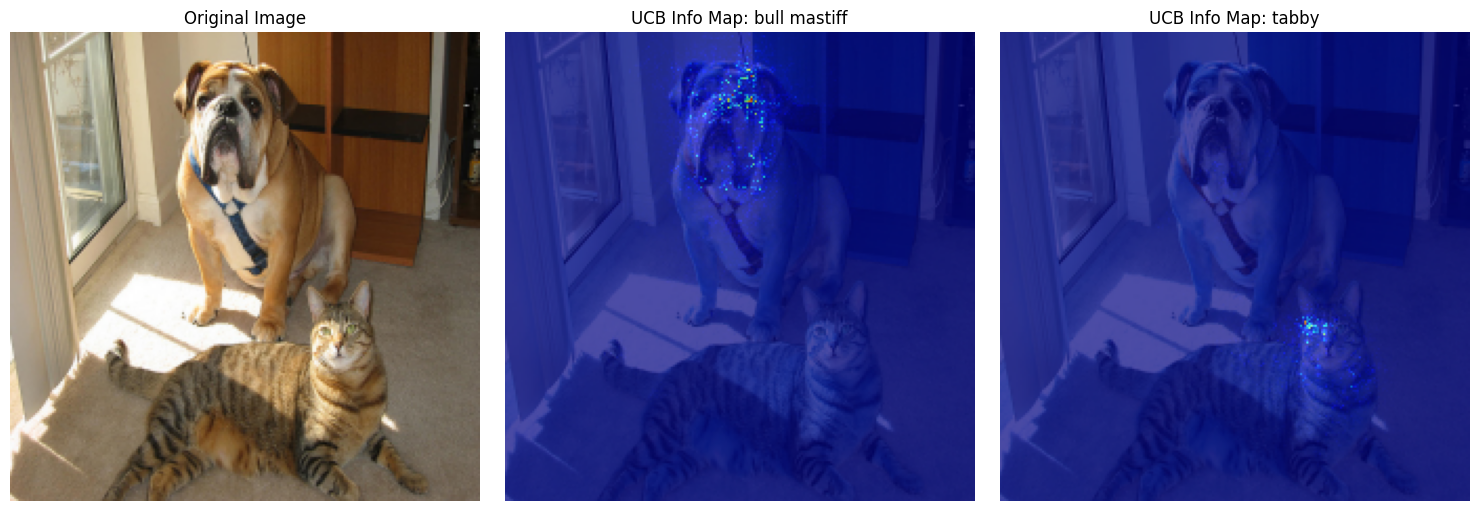

UCB-based information map saved to bull mastiff_tabby/image_info_map.png


In [10]:
generate_image_importance_map(
        image_path=IMAGE_PATH,
        model=model,
        labels=labels,
        reg_params=reg_params,
        ucb_iterations=0,
        top_percent=0.7,
        batch_size_for_perturbations=1,
        n_init=40,
        csv_path="ucb_log.csv",
        calculate=False
    )

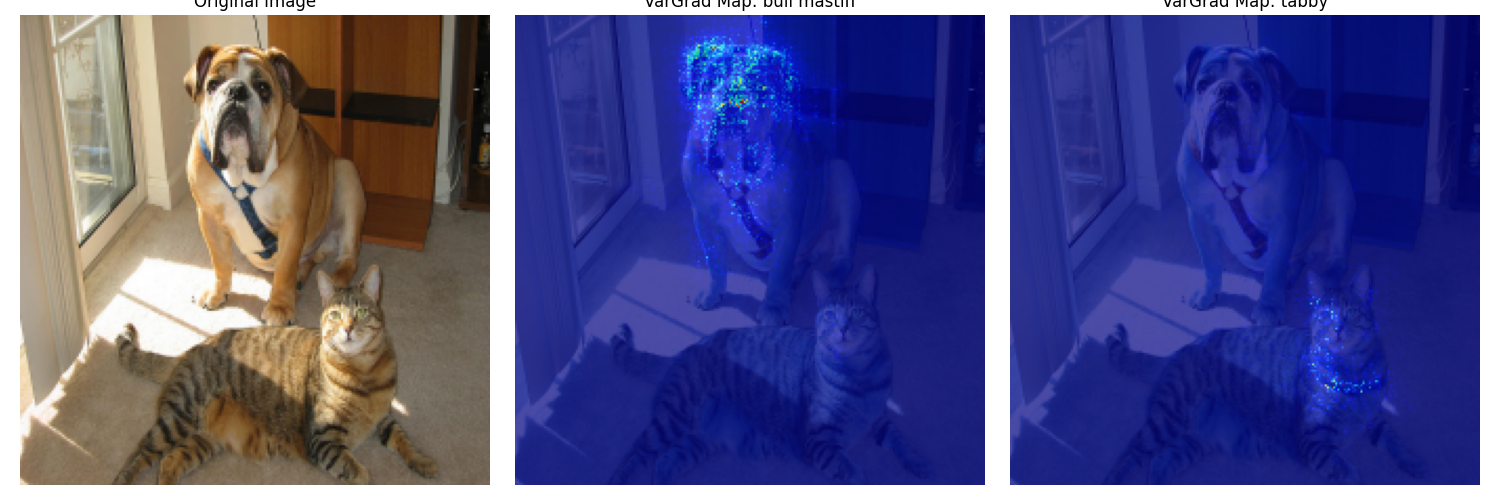

Bull mastif is 243
Tabby is 281